In [37]:
wine = read.csv("https://peter.butka.website.tuke.sk/test/winequality.csv")

In [38]:
head(wine)

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,7.0,0.27,0.36,20.7,0.045,45,170,1.0010,3.00,0.45,8.8,6
2,6.3,0.30,0.34,1.6,0.049,14,132,0.9940,3.30,0.49,9.5,6
3,8.1,0.28,0.40,6.9,0.050,30,97,0.9951,3.26,0.44,10.1,6
4,7.2,0.23,0.32,8.5,0.058,47,186,0.9956,3.19,0.40,9.9,6
5,7.2,0.23,0.32,8.5,0.058,47,186,0.9956,3.19,0.40,9.9,6
6,8.1,0.28,0.40,6.9,0.050,30,97,0.9951,3.26,0.44,10.1,6


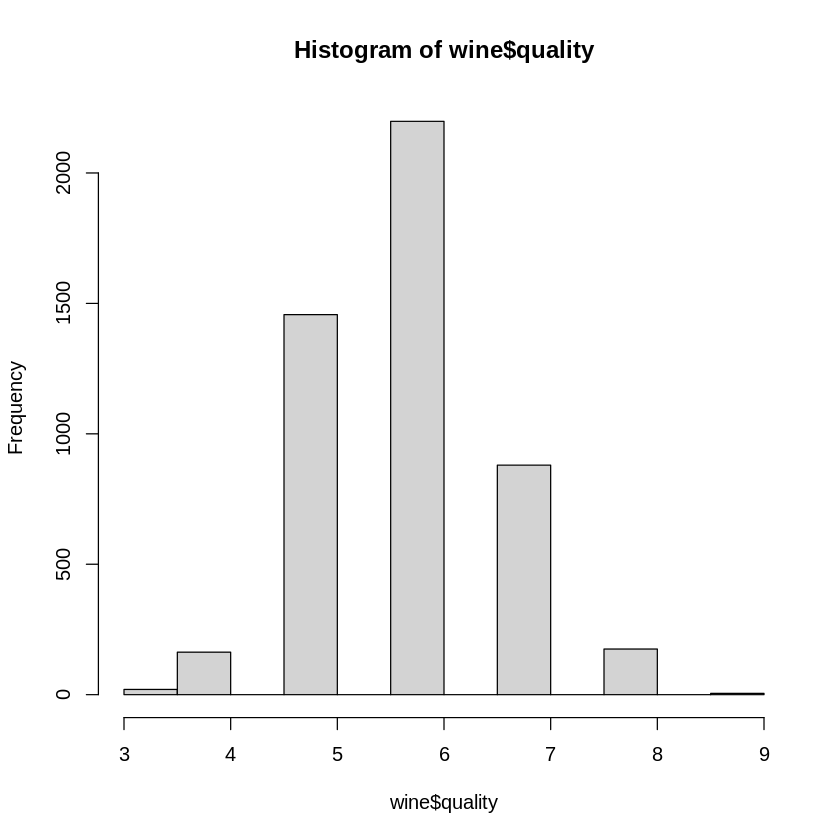

In [39]:
hist(wine$quality)

In [40]:
cor(wine)

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
fixed.acidity,1.00000000,-0.02269729,0.289180698,0.08902070,0.02308564,-0.0493958591,0.091069756,0.26533101,-0.4258582910,-0.01714299,-0.12088112,-0.113662831
volatile.acidity,-0.02269729,1.00000000,-0.149471811,0.06428606,0.07051157,-0.0970119393,0.089260504,0.02711385,-0.0319153683,-0.03572815,0.06771794,-0.194722969
citric.acid,0.28918070,-0.14947181,1.000000000,0.09421162,0.11436445,0.0940772210,0.121130798,0.14950257,-0.1637482114,0.06233094,-0.07572873,-0.009209091
residual.sugar,0.08902070,0.06428606,0.094211624,1.00000000,0.08868454,0.2990983537,0.401439311,0.83896645,-0.1941334540,-0.02666437,-0.45063122,-0.097576829
chlorides,0.02308564,0.07051157,0.114364448,0.08868454,1.00000000,0.1013923521,0.198910300,0.25721132,-0.0904394560,0.01676288,-0.36018871,-0.209934411
free.sulfur.dioxide,-0.04939586,-0.09701194,0.094077221,0.29909835,0.10139235,1.0000000000,0.615500965,0.29421041,-0.0006177961,0.05921725,-0.25010394,0.008158067
total.sulfur.dioxide,0.09106976,0.08926050,0.121130798,0.40143931,0.19891030,0.6155009650,1.000000000,0.52988132,0.0023209718,0.13456237,-0.44889210,-0.174737218
density,0.26533101,0.02711385,0.149502571,0.83896645,0.25721132,0.2942104109,0.529881324,1.00000000,-0.0935914935,0.07449315,-0.78013762,-0.307123313
pH,-0.42585829,-0.03191537,-0.163748211,-0.19413345,-0.09043946,-0.0006177961,0.002320972,-0.09359149,1.0000000000,0.15595150,0.12143210,0.099427246
sulphates,-0.01714299,-0.03572815,0.062330940,-0.02666437,0.01676288,0.0592172458,0.134562367,0.07449315,0.1559514973,1.00000000,-0.01743277,0.053677877


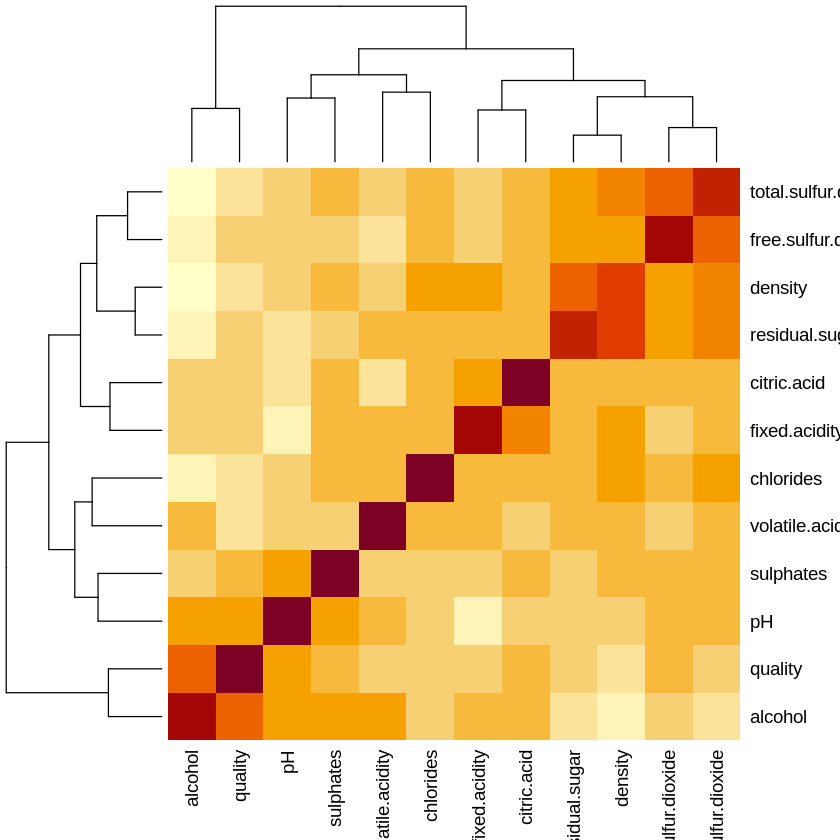

In [41]:
heatmap(cor(wine))

In [42]:
#Выберите топ-N атрибутов с наибольшей абсолютной корреляцией с целевым атрибутом.
#в нашем случае alcochol, pH, sulphates, citric.asid, free.sulfur.dioxide

In [43]:
ind = sample(2, nrow(wine), replace = TRUE, prob=c(0.7, 0.3))
train.data = wine[ind==1,]
test.data = wine[ind==2,] 

In [62]:
train = train.data[, c("alcohol", "pH", "sulphates", "citric.acid", "free.sulfur.dioxide")]
test = test.data[, c("alcohol", "pH", "sulphates", "citric.acid", "free.sulfur.dioxide")]

trainQ = train.data[, c("quality")]
testQ = test.data[, c("quality")]

In [67]:
my_model <- lm(quality ~ alcohol + pH + sulphates + citric.acid + free.sulfur.dioxide, data = train.data)
summary(my_model)


Call:
lm(formula = quality ~ alcohol + pH + sulphates + citric.acid + 
    free.sulfur.dioxide, data = train.data)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.7558 -0.5186 -0.0086  0.4920  3.2083 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)         1.1008175  0.3118275   3.530 0.000421 ***
alcohol             0.3355901  0.0114119  29.407  < 2e-16 ***
pH                  0.2331702  0.0925742   2.519 0.011823 *  
sulphates           0.4070984  0.1207677   3.371 0.000758 ***
citric.acid         0.1572229  0.1137393   1.382 0.166968    
free.sulfur.dioxide 0.0070220  0.0008122   8.646  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7842 on 3397 degrees of freedom
Multiple R-squared:  0.2128,	Adjusted R-squared:  0.2116 
F-statistic: 183.7 on 5 and 3397 DF,  p-value: < 2.2e-16


In [77]:
predicted_values <- predict(my_model, newdata = test.data)

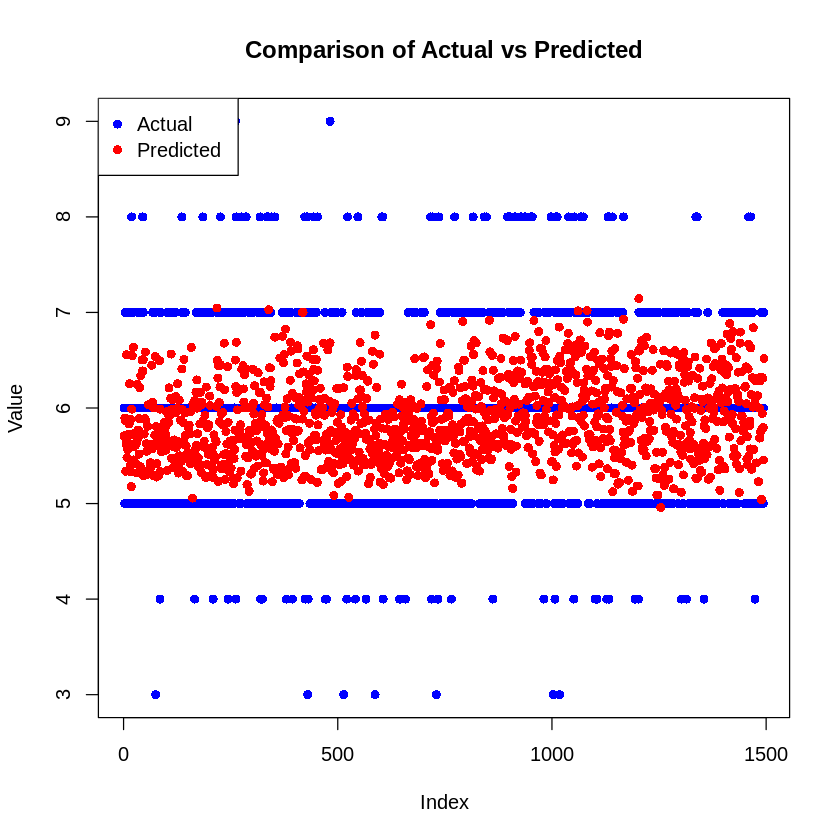

In [83]:
plot(test.data$quality, col = "blue", pch = 16, xlab = "Index", ylab = "Value", main = "Comparison of Actual vs Predicted")
points(predicted_values, col = "red", pch = 16)
legend("topleft", legend = c("Actual", "Predicted"), col = c("blue", "red"), pch = 16)
